# Direction 2: Per-Layer Learnable $t_d$ in HEA-TI
## Does a layer-dependent entangling-time schedule outperform a single global learnable $t_d$?

**Author:** Prashant Gupta  
**Institution:** IIT Kharagpur  
**Project context:** Follow-up notebook to the Direction 1 study

---

## Scientific motivation

Direction 1 established that making the XY evolution time $t_d$ learnable can strongly help some molecules and hurt others.  
This notebook asks a more refined question:

> If one shared learnable $t_d$ is useful, can we do even better by learning a separate $t_d^{(d)}$ for each HEA-TI layer?

That is a genuine **Direction 2** question, because it moves from *one extra classical control parameter* to a *schedule of native entangling times* across the circuit.

## What this notebook does

1. Rebuilds the molecular Hamiltonians and HEA-TI circuit families.
2. Compares three parametrisation modes at fixed depth $D=4$:
   - **fixed** $t_d = 0.4$
   - **global learnable** shared $t_d$
   - **layerwise learnable** schedule $(t_d^{(0)}, t_d^{(1)}, \dots, t_d^{(D-1)})$
3. Studies ideal noiseless performance across H$_2$, LiH, BeH$_2$, and H$_2$O.
4. Examines the learned layerwise schedules and their nonuniformity.
5. Runs a low-noise benchmark across H$_2$, LiH, BeH$_2$, and H$_2$O.
6. Tests depth scaling across the same four-molecule set.
7. Optionally probes LiH geometry dependence.

## Main outputs produced by the notebook

- `direction2_ideal_checkpoint.json`
- `direction2_noisy_checkpoint.json`
- `direction2_depth_checkpoint.json`

These files are written so the study can be resumed or plotted later without rerunning everything.


---
## Section 1: Installation

Run the next cell once per Colab session. It installs the full Qiskit + PySCF stack needed for the molecular, ansatz, and noisy-simulation workflows.

### Packages used here
- `qiskit[visualization]`
- `qiskit-aer`
- `qiskit-nature[pyscf]`
- `qiskit-algorithms`
- `pyscf`
- `numpy`, `scipy`, `matplotlib`
- `pylatexenc`


In [1]:
# -----------------------------------------------------------------------------
# CELL 1: Install required packages -- run once per Colab session
# -----------------------------------------------------------------------------
import subprocess, sys
packages=['qiskit[visualization]','qiskit-aer','qiskit-nature[pyscf]','qiskit-algorithms','pyscf','numpy','scipy','matplotlib','pylatexenc']
for pkg in packages:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
print('Packages installed.')


Packages installed.


---
## Section 2: Imports and Global Study Configuration

The next cell collects all imports, plotting style, study-wide constants, and helper formatting utilities.

### Fixed design choices
- Seeds: `42, 100, 2026, 777`
- Main depth for the core comparison: `D = 4`
- Baseline fixed value: `t_d = 0.4`
- Chemical accuracy threshold: `1.6 mHa`
- Reference low-noise benchmark point: `p1 = 1e-6`, `p2 = 1e-5`

This mirrors the clean project-notebook style used in the Direction 1 notebooks.


In [2]:
# -----------------------------------------------------------------------------
# CELL 2: Imports, plotting style, and global configuration
# -----------------------------------------------------------------------------
import os, gc, time, json, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')
os.environ['KMP_WARNINGS']='0'
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import LieTrotter
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_aer.primitives import EstimatorV2
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
plt.rcParams.update({'font.family':'serif','font.size':11,'axes.linewidth':1.2,'figure.dpi':120})
SEEDS=[42,100,2026,777]
ALL_MOLECULES=['H2','LiH','BeH2','H2O']
TD_MODES=['fixed','global','layerwise']
DEPTH=4
FIXED_TD=0.4
CHEM_ACC=1.6
NOISE_REF={'p1':1e-6,'p2':1e-5}

def format_noise_pct(prob):
    pct=100.0*prob
    return f'{pct:.4f}%' if pct<0.01 else (f'{pct:.3f}%' if pct<0.1 else f'{pct:.2f}%')

def make_serialisable(obj):
    if isinstance(obj, dict): return {k: make_serialisable(v) for k,v in obj.items()}
    if isinstance(obj, (list,tuple)): return [make_serialisable(v) for v in obj]
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, (np.float64,np.float32,np.complex128)): return float(np.real(obj))
    if isinstance(obj, (np.int64,np.int32)): return int(obj)
    return obj

print('Imports OK.', SEEDS, NOISE_REF)


Imports OK. [42, 100, 2026, 777] {'p1': 1e-06, 'p2': 1e-05}


---
## Section 3: Molecular Problem Setup and HEA-TI Circuit Builder

This section defines the molecular Hamiltonians and the three HEA-TI parametrisation modes used in the study.

### Molecules included
- H$_2$
- LiH
- BeH$_2$
- H$_2$O

### Three $t_d$ modes
1. **fixed**: all layers use the constant `0.4`
2. **global**: one shared learnable `t_d`
3. **layerwise**: one learnable `t_d_d` per layer

### What the first code cell in this section provides
- molecule getter with active-space handling
- XY Hamiltonian builder
- HEA-TI circuit factory with fixed/global/layerwise scheduling
- CX-count and depth extraction for parity checks


In [3]:
# -----------------------------------------------------------------------------
# CELL 3: Molecule getter + XY Hamiltonian + HEA-TI schedule builder
# -----------------------------------------------------------------------------
def get_molecule(name, bond_distance=None):
    mapper=JordanWignerMapper()
    if name=='H2':
        R=bond_distance or 0.74
        driver=PySCFDriver(atom=f'H 0 0 0; H 0 0 {R}', basis='sto3g')
        problem=driver.run()
        qop=mapper.map(problem.hamiltonian.second_q_op())
        offset=problem.hamiltonian.nuclear_repulsion_energy
        nq=qop.num_qubits; npart=problem.num_particles
    elif name=='LiH':
        R=bond_distance or 1.505
        driver=PySCFDriver(atom=f'Li 0 0 0; H 0 0 {R}', basis='sto3g')
        problem=driver.run()
        t=ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
        t.prepare_active_space(sum(problem.num_particles), problem.num_spin_orbitals//2)
        ham=t.transform_hamiltonian(problem.hamiltonian)
        qop=mapper.map(ham.second_q_op())
        offset=ham.constants.get('nuclear_repulsion_energy',0)+ham.constants.get('ActiveSpaceTransformer',0)
        nq=qop.num_qubits; npart=(1,1)
    elif name=='BeH2':
        R=bond_distance or 1.33
        driver=PySCFDriver(atom=f'Be 0 0 0; H 0 0 {R}; H 0 0 -{R}', basis='sto3g', charge=0, spin=0)
        problem=driver.run()
        t=ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
        t.prepare_active_space(sum(problem.num_particles), problem.num_spin_orbitals//2)
        ham=t.transform_hamiltonian(problem.hamiltonian)
        qop=mapper.map(ham.second_q_op())
        offset=ham.constants.get('nuclear_repulsion_energy',0)+ham.constants.get('ActiveSpaceTransformer',0)
        nq=qop.num_qubits; npart=(1,1)
    elif name=='H2O':
        Roh=0.9572; ang=np.radians(104.52/2.0); hx=Roh*np.sin(ang); hz=Roh*np.cos(ang)
        driver=PySCFDriver(atom=f'O 0 0 0; H {hx:.4f} 0 {hz:.4f}; H -{hx:.4f} 0 {hz:.4f}', basis='sto3g', charge=0, spin=0)
        problem=driver.run()
        t=ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
        t.prepare_active_space(sum(problem.num_particles), problem.num_spin_orbitals//2)
        ham=t.transform_hamiltonian(problem.hamiltonian)
        qop=mapper.map(ham.second_q_op())
        offset=ham.constants.get('nuclear_repulsion_energy',0)+ham.constants.get('ActiveSpaceTransformer',0)
        nq=qop.num_qubits; npart=(1,1)
    else:
        raise ValueError(name)
    exact=NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop).eigenvalue+offset
    return qop, offset, float(np.real(exact)), nq, npart

def build_xy_hamiltonian(nq):
    pauli=[]
    for i in range(nq):
        for j in range(i+1,nq):
            J=1.0/(abs(i-j)**1.5)
            xx=['I']*nq; yy=['I']*nq; xx[i]=xx[j]='X'; yy[i]=yy[j]='Y'
            pauli.extend([(''.join(xx),J),(''.join(yy),J)])
    return SparsePauliOp.from_list(pauli)

def build_hea_ti_schedule(nq, npart, mapper, num_layers=4, fixed_td=0.4, td_mode='fixed'):
    init=HartreeFock(nq//2, npart, mapper)
    Hxy=build_xy_hamiltonian(nq)
    qc=QuantumCircuit(nq); qc.compose(init, inplace=True); qc.barrier()
    shared=Parameter('t_d') if td_mode=='global' else None
    for d in range(num_layers):
        for q in range(nq): qc.rz(Parameter(f'theta_{d}_{q}'), q)
        evo_time=fixed_td if td_mode=='fixed' else (shared if td_mode=='global' else Parameter(f't_d_{d}'))
        qc.append(PauliEvolutionGate(Hxy, time=evo_time, synthesis=LieTrotter(reps=1)), range(nq))
    tqc=transpile(qc, basis_gates=['rz','rx','ry','cx'], optimization_level=1)
    params=list(tqc.parameters)
    td_names=[p.name for p in params if p.name=='t_d' or p.name.startswith('t_d_')]
    return tqc, params, td_names, tqc.count_ops().get('cx',0), tqc.depth()


### Multi-start initialisation, noise engine, and VQE runner

The next cell contains the reusable execution utilities.

### Why these utilities matter
- `make_initial_point(...)` ensures consistent initialisation logic across all modes.
- `build_estimator(...)` cleanly switches between ideal statevector and noisy density-matrix estimation.
- `run_vqe_multistart(...)` performs the multi-seed study and returns all quantities needed later:
  best energy, mean error, standard deviation, evaluation counts, convergence curves, and learned $t_d$ schedules.


In [4]:
# -----------------------------------------------------------------------------
# CELL 4: Initialisation utilities, estimators, and multi-start VQE runner
# -----------------------------------------------------------------------------
def make_initial_point(params, td_names, rng, fixed_td=0.4):
    ntd=len(td_names); mid=0.5*(ntd-1) if ntd>1 else 0.0; vals=[]
    for p in params:
        n=p.name
        if n=='t_d': vals.append(float(fixed_td+rng.normal(0.0,0.02)))
        elif n.startswith('t_d_'):
            idx=int(n.split('_')[-1]); drift=0.03*(idx-mid)/max(ntd-1,1); vals.append(float(fixed_td+drift+rng.normal(0.0,0.01)))
        else: vals.append(float(rng.uniform(-0.1,0.1)))
    return np.array(vals, dtype=float)

def extract_td_vector(optimal_parameters, td_names):
    if not optimal_parameters or not td_names: return []
    m={p.name: float(v) for p,v in optimal_parameters.items() if hasattr(p,'name')}
    return [m[n] for n in td_names if n in m]

def schedule_nonuniformity(td_vector):
    arr=np.asarray(td_vector, dtype=float)
    return 0.0 if arr.size<=1 else float(np.std(arr))

def build_estimator(noisy=False, p1=None, p2=None):
    if not noisy: return StatevectorEstimator()
    nm=NoiseModel(); nm.add_all_qubit_quantum_error(depolarizing_error(p1,1), ['rz','rx','ry']); nm.add_all_qubit_quantum_error(depolarizing_error(p2,2), ['cx'])
    return EstimatorV2(options={'default_precision':0.0,'backend_options':{'noise_model':nm,'method':'density_matrix'}})

def run_vqe_multistart(label, qop, ansatz, params, td_names, offset, exact, maxiter=500, noisy=False, p1=None, p2=None, fixed_td=0.4, verbose=False):
    Es=[]; errs=[]; evs=[]; curves=[]; tdvecs=[]; bestE=None; besttd=[]
    for seed in SEEDS:
        rng=np.random.default_rng(seed); init=make_initial_point(params, td_names, rng, fixed_td=fixed_td); est=build_estimator(noisy=noisy, p1=p1, p2=p2); opt=L_BFGS_B(maxiter=maxiter); curve=[]
        def cb(*args):
            if len(args)>=3: curve.append(float(args[2]))
        vqe=VQE(est, ansatz, opt, initial_point=init, callback=cb)
        res=vqe.compute_minimum_eigenvalue(qop)
        E=float(np.real(res.eigenvalue))+offset; err=abs(E-exact)*1000.0; td=extract_td_vector(res.optimal_parameters, td_names)
        Es.append(E); errs.append(err); evs.append(int(res.cost_function_evals)); curves.append(curve)
        if td: tdvecs.append(td)
        if bestE is None or E<bestE: bestE=E; besttd=td
        if verbose: print(label, seed, E, err, td)
    return {'best_E':float(min(Es)),'mean_E':float(np.mean(Es)),'std_E':float(np.std(Es)),'best_err_mha':float(min(errs)),'mean_err_mha':float(np.mean(errs)),'std_err_mha':float(np.std(errs)),'all_E':Es,'all_err_mha':errs,'mean_evals':float(np.mean(evs)),'all_evals':evs,'convergence_curves':curves,'td_vectors':tdvecs,'best_td_vector':besttd,'best_nonuniformity':schedule_nonuniformity(besttd)}

print('Core functions ready.')


Core functions ready.


---
## Section 4: Resource Parity Check and Ideal Direction 2 Benchmark at $D=4$

This is the first main experiment of the notebook.

### Questions answered here
1. Do the fixed/global/layerwise variants preserve **CX parity** at the same depth?
2. In the **ideal noiseless** limit, does a per-layer $t_d$ schedule outperform a single global learnable $t_d$?
3. How large is the scheduling gain relative to the original fixed-$t_d$ baseline?

The code cell below:
- builds all molecule data,
- constructs all three circuit families,
- prints the resource summary,
- runs the ideal multi-start VQE benchmark,
- saves `direction2_ideal_checkpoint.json`.


Resource summary at D=4
--------------------------------------------------------------------------------------
Mol    Mode       Qubits   CX       Depth    n_params   n_td    
--------------------------------------------------------------------------------------
H2     fixed      4        96       179      16         0       
H2     global     4        96       179      17         1       
H2     layerwise  4        96       179      20         4       
  -> CX parity: True
LiH    fixed      6        240      279      24         0       
LiH    global     6        240      279      25         1       
LiH    layerwise  6        240      279      28         4       
  -> CX parity: True
BeH2   fixed      6        240      279      24         0       
BeH2   global     6        240      279      25         1       
BeH2   layerwise  6        240      279      28         4       
  -> CX parity: True
H2O    fixed      6        240      279      24         0       
H2O    global     6     

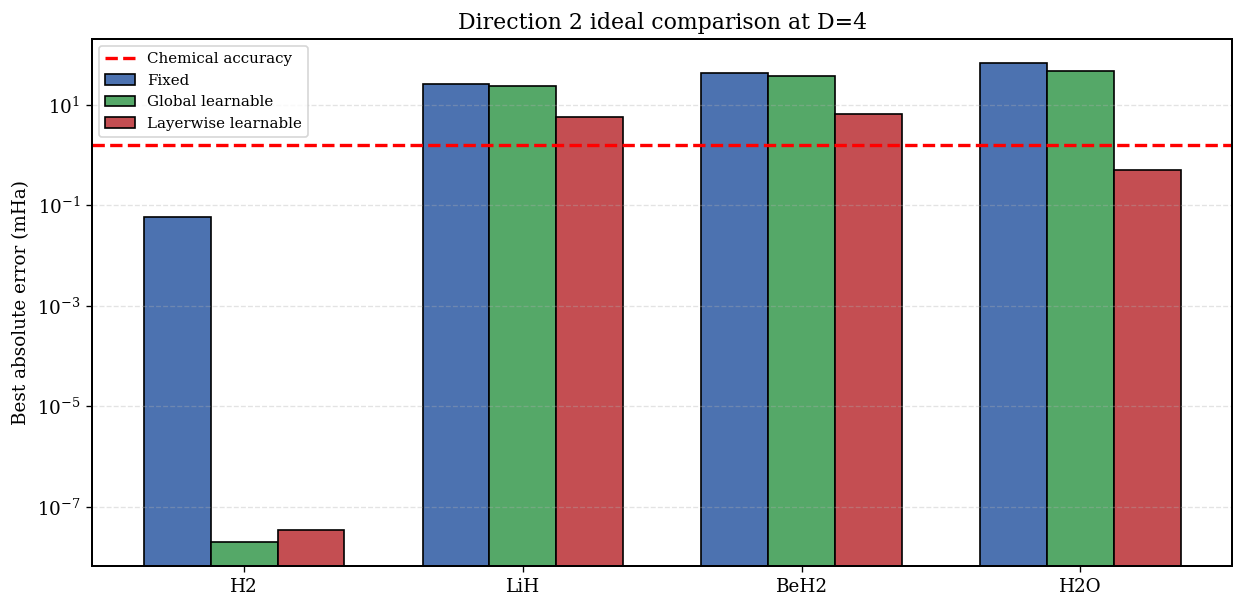

Saved direction2_ideal_checkpoint.json


In [ ]:
# -----------------------------------------------------------------------------
# CELL 5: Resource parity summary + ideal D=4 benchmark across all molecules
# -----------------------------------------------------------------------------
mapper=JordanWignerMapper()
molecule_data={}; resource_data={}; ideal_results={}
for mol in ALL_MOLECULES:
    qop, offset, exact, nq, npart=get_molecule(mol)
    molecule_data[mol]={'qubit_op':qop,'offset':offset,'exact':exact,'nq':nq,'npart':npart}
    resource_data[mol]={}
    for mode in TD_MODES:
        ans, params, td_names, cx, depth=build_hea_ti_schedule(nq, npart, mapper, num_layers=DEPTH, fixed_td=FIXED_TD, td_mode=mode)
        resource_data[mol][mode]={'ansatz':ans,'params':params,'td_names':td_names,'cx':cx,'depth':depth,'n_params':len(params),'n_td':len(td_names)}
print('Resource summary at D=4')
print('-'*86)
print(f'{"Mol":<6} {"Mode":<10} {"Qubits":<8} {"CX":<8} {"Depth":<8} {"n_params":<10} {"n_td":<8}')
print('-'*86)
for mol in ALL_MOLECULES:
    cxs=[]
    for mode in TD_MODES:
        r=resource_data[mol][mode]; cxs.append(r['cx'])
        print(f'{mol:<6} {mode:<10} {molecule_data[mol]["nq"]:<8} {r["cx"]:<8} {r["depth"]:<8} {r["n_params"]:<10} {r["n_td"]:<8}')
    print('  -> CX parity:', len(set(cxs))==1)

IDEAL_MAXITER=600
for mol in ALL_MOLECULES:
    print('Running ideal benchmark for', mol)
    ideal_results[mol]={}
    for mode in TD_MODES:
        ideal_results[mol][mode]=run_vqe_multistart(f'{mol}-{mode}', molecule_data[mol]['qubit_op'], resource_data[mol][mode]['ansatz'], resource_data[mol][mode]['params'], resource_data[mol][mode]['td_names'], molecule_data[mol]['offset'], molecule_data[mol]['exact'], maxiter=IDEAL_MAXITER, noisy=False, fixed_td=FIXED_TD)
        gc.collect()
    fE=ideal_results[mol]['fixed']['best_E']; gE=ideal_results[mol]['global']['best_E']; lE=ideal_results[mol]['layerwise']['best_E']
    ideal_results[mol]['DeltaE_gap_global_mha']=float((fE-gE)*1000.0)
    ideal_results[mol]['DeltaE_gap_layer_mha']=float((fE-lE)*1000.0)
    ideal_results[mol]['DeltaE_sched_mha']=float((gE-lE)*1000.0)
    ideal_results[mol]['eta_nonuniform']=float(np.mean([schedule_nonuniformity(v) for v in ideal_results[mol]['layerwise']['td_vectors']])) if ideal_results[mol]['layerwise']['td_vectors'] else 0.0

print()
print('Ideal summary')
print('-'*118)
print(f'{"Mol":<6} {"Fixed err":<12} {"Global err":<12} {"Layer err":<12} {"Delta_gap_g":<14} {"Delta_gap_l":<14} {"Delta_sched":<14} {"eta":<10}')
print('-'*118)
for mol in ALL_MOLECULES:
    print(f'{mol:<6} {ideal_results[mol]["fixed"]["best_err_mha"]:<12.4f} {ideal_results[mol]["global"]["best_err_mha"]:<12.4f} {ideal_results[mol]["layerwise"]["best_err_mha"]:<12.4f} {ideal_results[mol]["DeltaE_gap_global_mha"]:<14.4f} {ideal_results[mol]["DeltaE_gap_layer_mha"]:<14.4f} {ideal_results[mol]["DeltaE_sched_mha"]:<14.4f} {ideal_results[mol]["eta_nonuniform"]:<10.4f}')

x=np.arange(len(ALL_MOLECULES)); w=0.24
fig, ax=plt.subplots(figsize=(10.5,5.2))
ax.bar(x-w,[ideal_results[m]['fixed']['best_err_mha'] for m in ALL_MOLECULES],width=w,label='Fixed',color='#4C72B0',edgecolor='black')
ax.bar(x,[ideal_results[m]['global']['best_err_mha'] for m in ALL_MOLECULES],width=w,label='Global learnable',color='#55A868',edgecolor='black')
ax.bar(x+w,[ideal_results[m]['layerwise']['best_err_mha'] for m in ALL_MOLECULES],width=w,label='Layerwise learnable',color='#C44E52',edgecolor='black')
ax.axhline(CHEM_ACC,color='red',linestyle='--',linewidth=2,label='Chemical accuracy')
ax.set_xticks(x); ax.set_xticklabels(ALL_MOLECULES); ax.set_yscale('log'); ax.set_ylabel('Best absolute error (mHa)'); ax.set_title('Direction 2 ideal comparison at D=4'); ax.grid(axis='y',linestyle='--',alpha=0.35); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
with open('direction2_ideal_checkpoint.json','w') as f: json.dump(make_serialisable(ideal_results), f, indent=2)
print('Saved direction2_ideal_checkpoint.json')


### Reading the ideal benchmark plots

The next plotting cell produces two diagnostics:

1. **Best-error comparison** across fixed/global/layerwise modes.
2. **Layerwise schedule analysis**, including the nonuniformity metric `eta_nonuniform` and its correlation with the schedule gain `DeltaE_sched`.

This is the key visual test of whether the extra flexibility of a layer-dependent schedule is actually being used in a meaningful way.


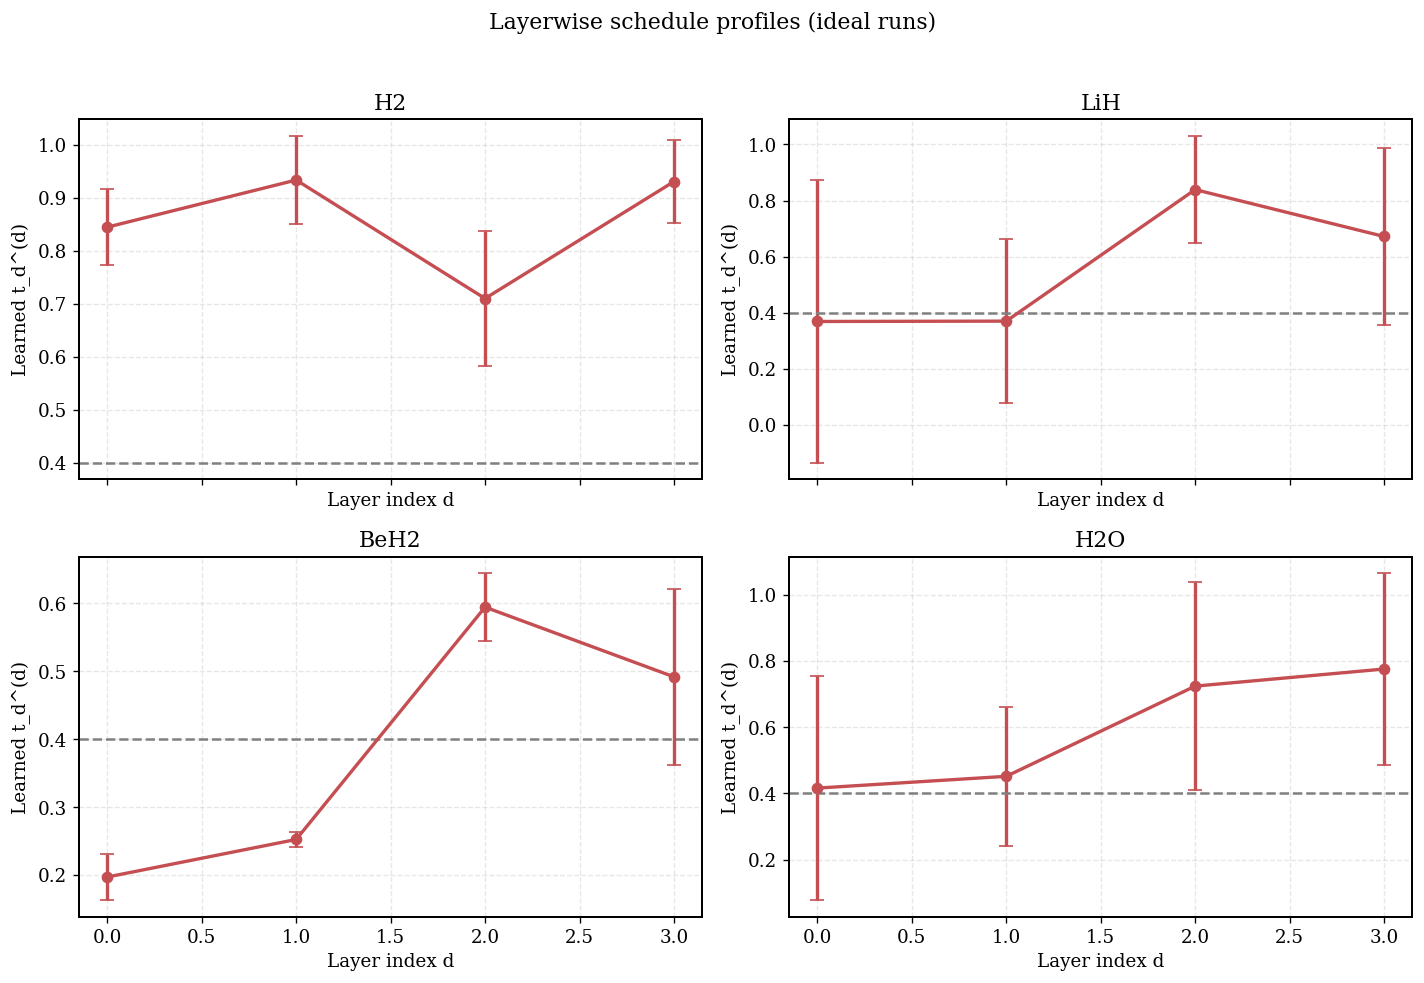

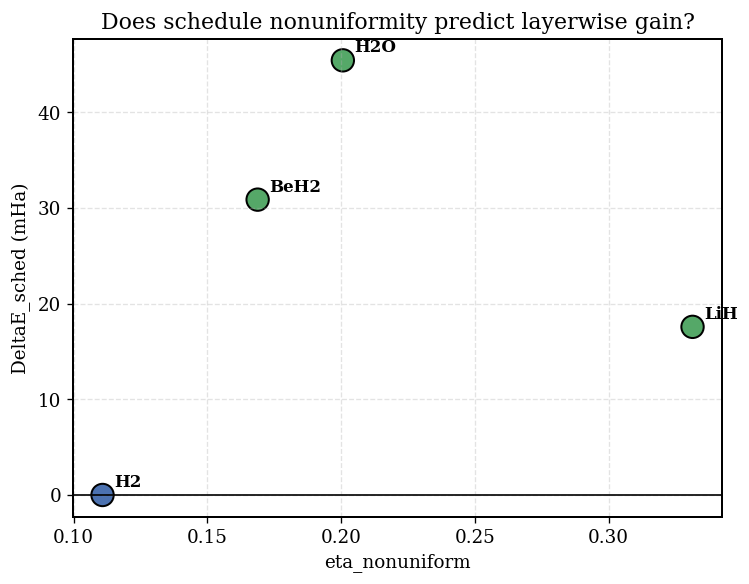

Pearson r(eta, DeltaE_sched) = 0.2033, p = 0.7967


In [ ]:
# -----------------------------------------------------------------------------
# CELL 6: Ideal-result visualisations and schedule diagnostics
# -----------------------------------------------------------------------------
fig, axes=plt.subplots(2,2,figsize=(12,8),sharex=True); axes=axes.flatten()
for i,mol in enumerate(ALL_MOLECULES):
    ax=axes[i]; vecs=ideal_results[mol]['layerwise']['td_vectors']
    if vecs:
        arr=np.array(vecs,dtype=float); mu=arr.mean(axis=0); sd=arr.std(axis=0); layers=np.arange(arr.shape[1])
        ax.errorbar(layers, mu, yerr=sd, fmt='o-', color='#C44E52', linewidth=2, capsize=4)
        ax.axhline(FIXED_TD, color='gray', linestyle='--', linewidth=1.5)
    ax.set_title(mol); ax.set_xlabel('Layer index d'); ax.set_ylabel('Learned t_d^(d)'); ax.grid(True, linestyle='--', alpha=0.3)
fig.suptitle('Layerwise schedule profiles (ideal runs)', y=1.02); plt.tight_layout(); plt.show()

etas=[ideal_results[m]['eta_nonuniform'] for m in ALL_MOLECULES]
delta=[ideal_results[m]['DeltaE_sched_mha'] for m in ALL_MOLECULES]
plt.figure(figsize=(6.4,5.0))
plt.scatter(etas, delta, s=180, c=['#55A868' if y>0 else '#4C72B0' for y in delta], edgecolors='black', linewidth=1.2)
for mol, x, y in zip(ALL_MOLECULES, etas, delta): plt.annotate(mol, (x,y), textcoords='offset points', xytext=(7,5), fontsize=10, fontweight='bold')
plt.axhline(0.0, color='black', linewidth=1.0); plt.xlabel('eta_nonuniform'); plt.ylabel('DeltaE_sched (mHa)'); plt.title('Does schedule nonuniformity predict layerwise gain?'); plt.grid(True, linestyle='--', alpha=0.35); plt.tight_layout(); plt.show()
if len(ALL_MOLECULES)>=2:
    corr=pearsonr(etas, delta); print(f'Pearson r(eta, DeltaE_sched) = {corr.statistic:.4f}, p = {corr.pvalue:.4f}')


---
## Section 5: Low-Noise Benchmark

Direction 1 showed that the effect of learnable $t_d$ becomes scientifically interesting only after noise is introduced.  
This section keeps the noise in a **chemically meaningful low-noise regime** while extending the benchmark across H$_2$, LiH, BeH$_2$, and H$_2$O.

### Why extend the noisy benchmark to all four molecules?
- It checks whether the layerwise schedule trends seen in the ideal study survive in a realistic low-noise setting.
- It lets Direction 2 be compared molecule-by-molecule against the earlier Direction 1 benchmarks.
- It reveals whether the extra schedule freedom matters only for the simplest systems or also for the harder 6-qubit cases.

The next cell runs the noisy benchmark, prints the summary table, plots error and evaluation-count comparisons, and saves `direction2_noisy_checkpoint.json`.


Noisy benchmark molecules: ['H2', 'LiH', 'BeH2', 'H2O'] | p1= 0.0001% | p2= 0.0010%

Noisy summary
----------------------------------------------------------------------------------------
Mol    Mode         best err     mean err     mean evals   best td                   
----------------------------------------------------------------------------------------
H2     fixed        1.0623       2.4123       697.0        []                        
H2     global       1.0110       1.0450       1485.0       [0.4671]                  
H2     layerwise    0.9728       0.9938       3832.5       [0.9048, 0.8653, 0.8103, 0.801]
LiH    fixed        26.8238      30.7384      1187.5       []                        
LiH    global       24.4381      24.7834      4095.0       [1.3371]                  
LiH    layerwise    6.0393       7.7079       12651.2      [1.0966, 0.4049, 1.0396, 1.2237]
BeH2   fixed        44.0214      44.0214      1031.2       []                        
BeH2   global       38.8

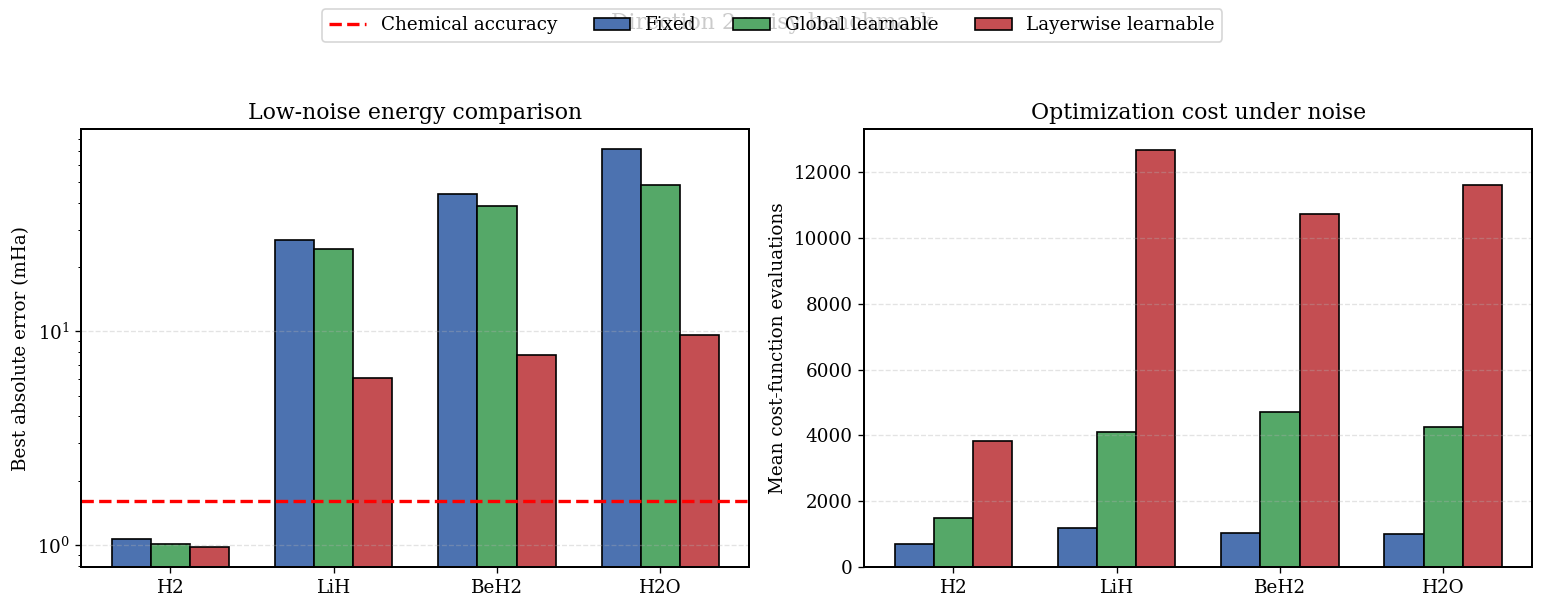

Saved direction2_noisy_checkpoint.json


In [ ]:
# -----------------------------------------------------------------------------
# CELL 7: Low-noise benchmark across all benchmark molecules
# -----------------------------------------------------------------------------
NOISY_MAXITER=500
noisy_molecules=list(ALL_MOLECULES)
noisy_results={}
print('Noisy benchmark molecules:', noisy_molecules, '| p1=', format_noise_pct(NOISE_REF['p1']), '| p2=', format_noise_pct(NOISE_REF['p2']))
for mol in noisy_molecules:
    noisy_results[mol]={}
    for mode in TD_MODES:
        noisy_results[mol][mode]=run_vqe_multistart(f'{mol}-{mode}-noisy', molecule_data[mol]['qubit_op'], resource_data[mol][mode]['ansatz'], resource_data[mol][mode]['params'], resource_data[mol][mode]['td_names'], molecule_data[mol]['offset'], molecule_data[mol]['exact'], maxiter=NOISY_MAXITER, noisy=True, p1=NOISE_REF['p1'], p2=NOISE_REF['p2'], fixed_td=FIXED_TD)
        gc.collect()
print()
print('Noisy summary')
print('-'*88)
print(f'{"Mol":<6} {"Mode":<12} {"best err":<12} {"mean err":<12} {"mean evals":<12} {"best td":<26}')
print('-'*88)
for mol in noisy_molecules:
    for mode in TD_MODES:
        r=noisy_results[mol][mode]
        print(f'{mol:<6} {mode:<12} {r["best_err_mha"]:<12.4f} {r["mean_err_mha"]:<12.4f} {r["mean_evals"]:<12.1f} {str(np.round(r["best_td_vector"],4).tolist()):<26}')

x=np.arange(len(noisy_molecules)); w=0.24
fig, axes=plt.subplots(1,2,figsize=(13,4.8))
axes[0].bar(x-w,[noisy_results[m]['fixed']['best_err_mha'] for m in noisy_molecules],width=w,label='Fixed',color='#4C72B0',edgecolor='black')
axes[0].bar(x,[noisy_results[m]['global']['best_err_mha'] for m in noisy_molecules],width=w,label='Global learnable',color='#55A868',edgecolor='black')
axes[0].bar(x+w,[noisy_results[m]['layerwise']['best_err_mha'] for m in noisy_molecules],width=w,label='Layerwise learnable',color='#C44E52',edgecolor='black')
axes[0].axhline(CHEM_ACC,color='red',linestyle='--',linewidth=2,label='Chemical accuracy'); axes[0].set_xticks(x); axes[0].set_xticklabels(noisy_molecules); axes[0].set_yscale('log'); axes[0].set_ylabel('Best absolute error (mHa)'); axes[0].set_title('Low-noise energy comparison'); axes[0].grid(axis='y',linestyle='--',alpha=0.35)
axes[1].bar(x-w,[noisy_results[m]['fixed']['mean_evals'] for m in noisy_molecules],width=w,label='Fixed',color='#4C72B0',edgecolor='black')
axes[1].bar(x,[noisy_results[m]['global']['mean_evals'] for m in noisy_molecules],width=w,label='Global learnable',color='#55A868',edgecolor='black')
axes[1].bar(x+w,[noisy_results[m]['layerwise']['mean_evals'] for m in noisy_molecules],width=w,label='Layerwise learnable',color='#C44E52',edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(noisy_molecules); axes[1].set_ylabel('Mean cost-function evaluations'); axes[1].set_title('Optimization cost under noise'); axes[1].grid(axis='y',linestyle='--',alpha=0.35)
handles, labels=axes[0].get_legend_handles_labels(); fig.legend(handles, labels, loc='upper center', ncol=4); fig.suptitle('Direction 2 noisy benchmark', y=1.05); plt.tight_layout(); plt.show()
with open('direction2_noisy_checkpoint.json','w') as f: json.dump(make_serialisable(noisy_results), f, indent=2)
print('Saved direction2_noisy_checkpoint.json')


---
## Section 6: Depth Scaling -- Global vs Layerwise Learnable Schedules

A per-layer schedule adds more classical freedom than a single shared $t_d$. The obvious next question is whether that extra freedom matters more as the circuit becomes deeper.

### What is tested here
- Depths: `D = 2, 4, 6`
- Molecules: `H2`, `LiH`, `BeH2`, `H2O`
- Modes compared: `global` vs `layerwise`

### Fresh-runtime note
This patched Cell 8 can rebuild the lightweight prerequisites it needs in a fresh Colab runtime, so you do **not** need to rerun the long ideal/noisy benchmark cells first.

If you are opening this notebook in a brand-new Colab session, run **Cell 1** once for package installation, then jump directly to **Cell 8**.

This cell saves either `direction2_depth_checkpoint.json` or `direction2_depth_checkpoint_fast.json` after the depth-scaling benchmark.


Fresh-runtime bootstrap for Cell 8: rebuilding imports, helpers, and molecule data.
Bootstrap complete. You can run the depth benchmark without rerunning Cells 5-7.
Depth benchmark molecules=['H2', 'LiH', 'BeH2', 'H2O'] | depths=[2, 4, 6] | FAST_DEPTH=False | maxiter=500 | seeds=[42, 100, 2026, 777] | completed jobs in checkpoint=0/24

[0/24] Starting depth study for H2
  - Running job 1/24: H2/D=2/global | maxiter=500 | starts=4
    done | best err=3.7499 mHa | mean evals=505.0 | wall=0.79 min | saved direction2_depth_checkpoint.json
  - Running job 2/24: H2/D=2/layerwise | maxiter=500 | starts=4
    done | best err=10.0430 mHa | mean evals=346.5 | wall=0.35 min | saved direction2_depth_checkpoint.json
  - Running job 3/24: H2/D=4/global | maxiter=500 | starts=4
    done | best err=0.0000 mHa | mean evals=1606.5 | wall=2.67 min | saved direction2_depth_checkpoint.json
  - Running job 4/24: H2/D=4/layerwise | maxiter=500 | starts=4
    done | best err=0.0000 mHa | mean evals=1795.5 | w

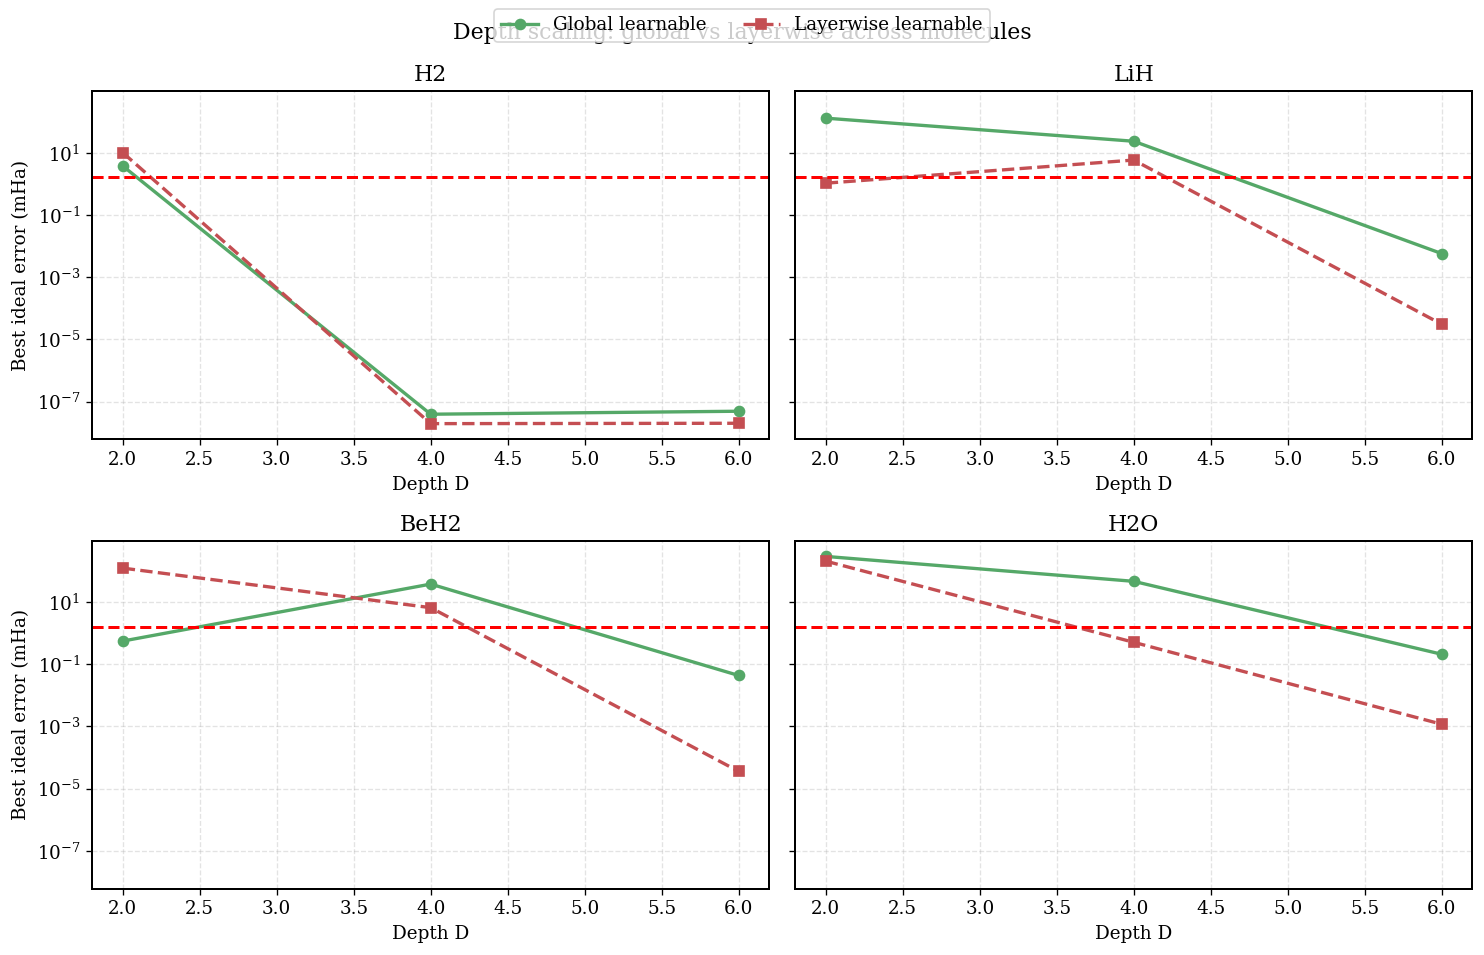

Saved direction2_depth_checkpoint.json


In [5]:
# -----------------------------------------------------------------------------
# CELL 8: Depth scaling study for global vs layerwise schedules
# This patched version can bootstrap itself in a fresh Colab runtime.
# -----------------------------------------------------------------------------
DEPTH_BOOTSTRAP=not all(name in globals() for name in ['SEEDS','ALL_MOLECULES','DEPTH','FIXED_TD','CHEM_ACC','format_noise_pct','make_serialisable','get_molecule','build_hea_ti_schedule','run_vqe_multistart','molecule_data','mapper'])
if DEPTH_BOOTSTRAP:
    print('Fresh-runtime bootstrap for Cell 8: rebuilding imports, helpers, and molecule data.')
    import os, gc, time, json, warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    warnings.filterwarnings('ignore')
    os.environ['KMP_WARNINGS']='0'
    try:
        from qiskit import QuantumCircuit, transpile
        from qiskit.circuit import Parameter
        from qiskit.circuit.library import PauliEvolutionGate
        from qiskit.quantum_info import SparsePauliOp
        from qiskit.synthesis import LieTrotter
        from qiskit.primitives import StatevectorEstimator
        from qiskit_algorithms import VQE, NumPyMinimumEigensolver
        from qiskit_algorithms.optimizers import L_BFGS_B
        from qiskit_aer.primitives import EstimatorV2
        from qiskit_aer.noise import NoiseModel, depolarizing_error
        from qiskit_nature.second_q.drivers import PySCFDriver
        from qiskit_nature.second_q.mappers import JordanWignerMapper
        from qiskit_nature.second_q.circuit.library import HartreeFock
        from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
    except ModuleNotFoundError as exc:
        raise RuntimeError('Fresh Colab detected without the required packages. Run CELL 1 once, then rerun this CELL 8.') from exc
    plt.rcParams.update({'font.family':'serif','font.size':11,'axes.linewidth':1.2,'figure.dpi':120})
    SEEDS=[42,100,2026,777]
    ALL_MOLECULES=['H2','LiH','BeH2','H2O']
    TD_MODES=['fixed','global','layerwise']
    DEPTH=4
    FIXED_TD=0.4
    CHEM_ACC=1.6
    NOISE_REF={'p1':1e-6,'p2':1e-5}

    def format_noise_pct(prob):
        pct=100.0*prob
        return f'{pct:.4f}%' if pct<0.01 else (f'{pct:.3f}%' if pct<0.1 else f'{pct:.2f}%')

    def make_serialisable(obj):
        if isinstance(obj, dict): return {k: make_serialisable(v) for k,v in obj.items()}
        if isinstance(obj, (list,tuple)): return [make_serialisable(v) for v in obj]
        if isinstance(obj, np.ndarray): return obj.tolist()
        if isinstance(obj, (np.float64,np.float32,np.complex128)): return float(np.real(obj))
        if isinstance(obj, (np.int64,np.int32)): return int(obj)
        return obj

    def get_molecule(name, bond_distance=None):
        mapper_local=JordanWignerMapper()
        if name=='H2':
            R=bond_distance or 0.74
            driver=PySCFDriver(atom=f'H 0 0 0; H 0 0 {R}', basis='sto3g')
            problem=driver.run()
            qop=mapper_local.map(problem.hamiltonian.second_q_op())
            offset=problem.hamiltonian.nuclear_repulsion_energy
            nq=qop.num_qubits; npart=problem.num_particles
        elif name=='LiH':
            R=bond_distance or 1.505
            driver=PySCFDriver(atom=f'Li 0 0 0; H 0 0 {R}', basis='sto3g')
            problem=driver.run()
            t=ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
            t.prepare_active_space(sum(problem.num_particles), problem.num_spin_orbitals//2)
            ham=t.transform_hamiltonian(problem.hamiltonian)
            qop=mapper_local.map(ham.second_q_op())
            offset=ham.constants.get('nuclear_repulsion_energy',0)+ham.constants.get('ActiveSpaceTransformer',0)
            nq=qop.num_qubits; npart=(1,1)
        elif name=='BeH2':
            R=bond_distance or 1.33
            driver=PySCFDriver(atom=f'Be 0 0 0; H 0 0 {R}; H 0 0 -{R}', basis='sto3g', charge=0, spin=0)
            problem=driver.run()
            t=ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
            t.prepare_active_space(sum(problem.num_particles), problem.num_spin_orbitals//2)
            ham=t.transform_hamiltonian(problem.hamiltonian)
            qop=mapper_local.map(ham.second_q_op())
            offset=ham.constants.get('nuclear_repulsion_energy',0)+ham.constants.get('ActiveSpaceTransformer',0)
            nq=qop.num_qubits; npart=(1,1)
        elif name=='H2O':
            Roh=0.9572; ang=np.radians(104.52/2.0); hx=Roh*np.sin(ang); hz=Roh*np.cos(ang)
            driver=PySCFDriver(atom=f'O 0 0 0; H {hx:.4f} 0 {hz:.4f}; H -{hx:.4f} 0 {hz:.4f}', basis='sto3g', charge=0, spin=0)
            problem=driver.run()
            t=ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
            t.prepare_active_space(sum(problem.num_particles), problem.num_spin_orbitals//2)
            ham=t.transform_hamiltonian(problem.hamiltonian)
            qop=mapper_local.map(ham.second_q_op())
            offset=ham.constants.get('nuclear_repulsion_energy',0)+ham.constants.get('ActiveSpaceTransformer',0)
            nq=qop.num_qubits; npart=(1,1)
        else:
            raise ValueError(name)
        exact=NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop).eigenvalue+offset
        return qop, offset, float(np.real(exact)), nq, npart

    def build_xy_hamiltonian(nq):
        pauli=[]
        for i in range(nq):
            for j in range(i+1,nq):
                J=1.0/(abs(i-j)**1.5)
                xx=['I']*nq; yy=['I']*nq; xx[i]=xx[j]='X'; yy[i]=yy[j]='Y'
                pauli.extend([(''.join(xx),J),(''.join(yy),J)])
        return SparsePauliOp.from_list(pauli)

    def build_hea_ti_schedule(nq, npart, mapper, num_layers=4, fixed_td=0.4, td_mode='fixed'):
        init=HartreeFock(nq//2, npart, mapper)
        Hxy=build_xy_hamiltonian(nq)
        qc=QuantumCircuit(nq); qc.compose(init, inplace=True); qc.barrier()
        shared=Parameter('t_d') if td_mode=='global' else None
        for d in range(num_layers):
            for q in range(nq): qc.rz(Parameter(f'theta_{d}_{q}'), q)
            evo_time=fixed_td if td_mode=='fixed' else (shared if td_mode=='global' else Parameter(f't_d_{d}'))
            qc.append(PauliEvolutionGate(Hxy, time=evo_time, synthesis=LieTrotter(reps=1)), range(nq))
        tqc=transpile(qc, basis_gates=['rz','rx','ry','cx'], optimization_level=1)
        params=list(tqc.parameters)
        td_names=[p.name for p in params if p.name=='t_d' or p.name.startswith('t_d_')]
        return tqc, params, td_names, tqc.count_ops().get('cx',0), tqc.depth()

    def make_initial_point(params, td_names, rng, fixed_td=0.4):
        ntd=len(td_names); mid=0.5*(ntd-1) if ntd>1 else 0.0; vals=[]
        for p in params:
            n=p.name
            if n=='t_d': vals.append(float(fixed_td+rng.normal(0.0,0.02)))
            elif n.startswith('t_d_'):
                idx=int(n.split('_')[-1]); drift=0.03*(idx-mid)/max(ntd-1,1); vals.append(float(fixed_td+drift+rng.normal(0.0,0.01)))
            else: vals.append(float(rng.uniform(-0.1,0.1)))
        return np.array(vals, dtype=float)

    def extract_td_vector(optimal_parameters, td_names):
        if not optimal_parameters or not td_names: return []
        m={p.name: float(v) for p,v in optimal_parameters.items() if hasattr(p,'name')}
        return [m[n] for n in td_names if n in m]

    def schedule_nonuniformity(td_vector):
        arr=np.asarray(td_vector, dtype=float)
        return 0.0 if arr.size<=1 else float(np.std(arr))

    def build_estimator(noisy=False, p1=None, p2=None):
        if not noisy: return StatevectorEstimator()
        nm=NoiseModel(); nm.add_all_qubit_quantum_error(depolarizing_error(p1,1), ['rz','rx','ry']); nm.add_all_qubit_quantum_error(depolarizing_error(p2,2), ['cx'])
        return EstimatorV2(options={'default_precision':0.0,'backend_options':{'noise_model':nm,'method':'density_matrix'}})

    def run_vqe_multistart(label, qop, ansatz, params, td_names, offset, exact, maxiter=500, noisy=False, p1=None, p2=None, fixed_td=0.4, verbose=False, seeds=None):
        Es=[]; errs=[]; evs=[]; curves=[]; tdvecs=[]; bestE=None; besttd=[]; wall=[]
        seed_list=list(SEEDS if seeds is None else seeds)
        for seed in seed_list:
            t0=time.time()
            rng=np.random.default_rng(seed); init=make_initial_point(params, td_names, rng, fixed_td=fixed_td); est=build_estimator(noisy=noisy, p1=p1, p2=p2); opt=L_BFGS_B(maxiter=maxiter); curve=[]
            def cb(*args):
                if len(args)>=3: curve.append(float(args[2]))
            vqe=VQE(est, ansatz, opt, initial_point=init, callback=cb)
            res=vqe.compute_minimum_eigenvalue(qop)
            E=float(np.real(res.eigenvalue))+offset; err=abs(E-exact)*1000.0; td=extract_td_vector(res.optimal_parameters, td_names)
            Es.append(E); errs.append(err); evs.append(int(res.cost_function_evals)); curves.append(curve); wall.append(float(time.time()-t0))
            if td: tdvecs.append(td)
            if bestE is None or E<bestE: bestE=E; besttd=td
            if verbose:
                td_print=np.round(td,4).tolist() if td else []
                print(f'{label} | seed={seed} | err={err:.4f} mHa | evals={int(res.cost_function_evals)} | wall={time.time()-t0:.1f}s | td={td_print}')
        return {'best_E':float(min(Es)),'mean_E':float(np.mean(Es)),'std_E':float(np.std(Es)),'best_err_mha':float(min(errs)),'mean_err_mha':float(np.mean(errs)),'std_err_mha':float(np.std(errs)),'all_E':Es,'all_err_mha':errs,'mean_evals':float(np.mean(evs)),'all_evals':evs,'convergence_curves':curves,'td_vectors':tdvecs,'best_td_vector':besttd,'best_nonuniformity':schedule_nonuniformity(besttd),'n_starts':len(seed_list),'seed_list':seed_list,'wall_seconds_per_seed':wall,'wall_seconds_total':float(np.sum(wall))}

    mapper=JordanWignerMapper()
    molecule_data={}
    for mol in ALL_MOLECULES:
        qop, offset, exact, nq, npart=get_molecule(mol)
        molecule_data[mol]={'qubit_op':qop,'offset':offset,'exact':exact,'nq':nq,'npart':npart}
    print('Bootstrap complete. You can run the depth benchmark without rerunning Cells 5-7.')
else:
    print('Cell 8 found existing runtime state; using current molecule_data and helper functions.')

FAST_DEPTH=False
RESUME_DEPTH=True
DEPTH_SEEDS=SEEDS[:2] if FAST_DEPTH else SEEDS
DEPTH_MAXITER=250 if FAST_DEPTH else 500
DEPTH_CHECKPOINT='direction2_depth_checkpoint_fast.json' if FAST_DEPTH else 'direction2_depth_checkpoint.json'
DEPTH_LIST=[2,4,6]
DEPTH_MOLECULES=list(ALL_MOLECULES)
DEPTH_MODES=['global','layerwise']
if RESUME_DEPTH and os.path.exists(DEPTH_CHECKPOINT):
    with open(DEPTH_CHECKPOINT,'r') as f: depth_results=json.load(f)
    print('Loaded existing depth checkpoint:', DEPTH_CHECKPOINT)
else:
    depth_results={}
for mol in DEPTH_MOLECULES:
    if mol not in depth_results: depth_results[mol]={}
    for mode in DEPTH_MODES:
        if mode not in depth_results[mol]: depth_results[mol][mode]=[]
completed_depth_jobs=sum(1 for mol in DEPTH_MOLECULES for D in DEPTH_LIST for mode in DEPTH_MODES if any((isinstance(item,dict) and int(item.get('depth',-1))==D) for item in depth_results.get(mol,{}).get(mode,[])))
total_depth_jobs=len(DEPTH_MOLECULES)*len(DEPTH_LIST)*len(DEPTH_MODES)
print(f'Depth benchmark molecules={DEPTH_MOLECULES} | depths={DEPTH_LIST} | FAST_DEPTH={FAST_DEPTH} | maxiter={DEPTH_MAXITER} | seeds={DEPTH_SEEDS} | completed jobs in checkpoint={completed_depth_jobs}/{total_depth_jobs}')
for mol in DEPTH_MOLECULES:
    mol_t0=time.time()
    print(f'\n[{completed_depth_jobs}/{total_depth_jobs}] Starting depth study for {mol}')
    for D in DEPTH_LIST:
        for mode in DEPTH_MODES:
            done_depths={int(item.get('depth')) for item in depth_results[mol][mode] if isinstance(item,dict) and 'depth' in item}
            if D in done_depths:
                print(f'  - Resume skip {mol}/D={D}/{mode} (already present in checkpoint)')
                continue
            job_no=completed_depth_jobs+1
            print(f'  - Running job {job_no}/{total_depth_jobs}: {mol}/D={D}/{mode} | maxiter={DEPTH_MAXITER} | starts={len(DEPTH_SEEDS)}')
            t0=time.time()
            ans, params, td_names, _, _=build_hea_ti_schedule(molecule_data[mol]['nq'], molecule_data[mol]['npart'], mapper, num_layers=D, fixed_td=FIXED_TD, td_mode=mode)
            run=run_vqe_multistart(f'{mol}-{mode}-D{D}', molecule_data[mol]['qubit_op'], ans, params, td_names, molecule_data[mol]['offset'], molecule_data[mol]['exact'], maxiter=DEPTH_MAXITER, noisy=False, fixed_td=FIXED_TD, verbose=False, seeds=DEPTH_SEEDS)
            depth_results[mol][mode].append({'depth':D,'best_err_mha':run['best_err_mha'],'best_td_vector':run['best_td_vector'],'eta_nonuniform':run['best_nonuniformity'],'mean_evals':run['mean_evals'],'n_starts':run['n_starts'],'seed_list':run['seed_list'],'maxiter_used':DEPTH_MAXITER,'fast_depth_mode':FAST_DEPTH,'wall_minutes':float((time.time()-t0)/60.0)})
            depth_results[mol][mode]=sorted(depth_results[mol][mode], key=lambda item: int(item.get('depth', 10**9)))
            completed_depth_jobs+=1
            with open(DEPTH_CHECKPOINT,'w') as f: json.dump(make_serialisable(depth_results), f, indent=2)
            r=depth_results[mol][mode][-1]
            best_err=r['best_err_mha']; mean_evals=r['mean_evals']
            print(f'    done | best err={best_err:.4f} mHa | mean evals={mean_evals:.1f} | wall={(time.time()-t0)/60.0:.2f} min | saved {DEPTH_CHECKPOINT}')
            gc.collect()
    print(f'  Molecule {mol} complete | molecule wall={(time.time()-mol_t0)/60.0:.2f} min')
for mol in DEPTH_MOLECULES:
    for mode in DEPTH_MODES:
        depth_results[mol][mode]=sorted(depth_results[mol][mode], key=lambda item: int(item.get('depth', 10**9)))



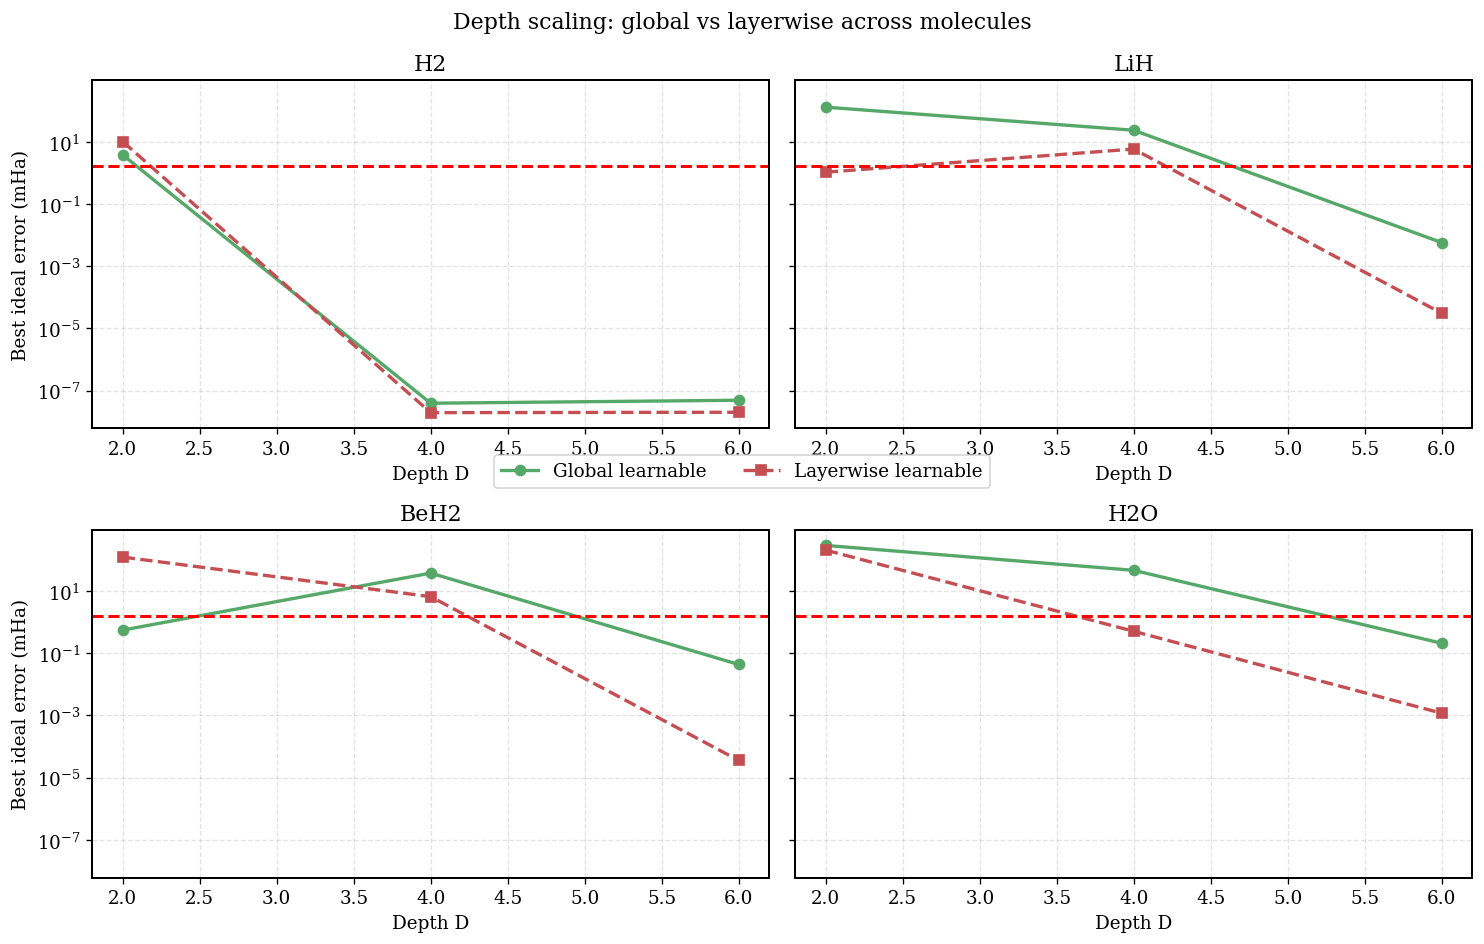

Saved direction2_depth_checkpoint.json


In [8]:
fig, axes=plt.subplots(2,2,figsize=(12.5,8),sharey=True)
axes=np.array(axes).reshape(-1)
for i,mol in enumerate(DEPTH_MOLECULES):
    global_curve={int(x['depth']):x['best_err_mha'] for x in depth_results[mol]['global']}
    layer_curve={int(x['depth']):x['best_err_mha'] for x in depth_results[mol]['layerwise']}
    axes[i].plot(DEPTH_LIST,[global_curve[d] for d in DEPTH_LIST],'o-',color='#55A868',linewidth=2,label='Global learnable')
    axes[i].plot(DEPTH_LIST,[layer_curve[d] for d in DEPTH_LIST],'s--',color='#C44E52',linewidth=2,label='Layerwise learnable')
    axes[i].axhline(CHEM_ACC,color='red',linestyle='--',linewidth=1.8); axes[i].set_title(mol); axes[i].set_xlabel('Depth D'); axes[i].set_yscale('log'); axes[i].grid(True, linestyle='--', alpha=0.35)
    if i % 2 == 0: axes[i].set_ylabel('Best ideal error (mHa)')
for ax in axes[len(DEPTH_MOLECULES):]: ax.axis('off')
handles, labels=axes[0].get_legend_handles_labels(); fig.legend(handles, labels, loc='center', ncol=3); fig.suptitle('Depth scaling: global vs layerwise across molecules', y=0.98); plt.tight_layout(); plt.show()
with open(DEPTH_CHECKPOINT,'w') as f: json.dump(make_serialisable(depth_results), f, indent=2)
print('Saved', DEPTH_CHECKPOINT)

---
## Section 7: Optional LiH Geometry Pilot

This final code cell is intentionally optional.

If `RUN_GEOMETRY_PILOT = True`, the notebook samples several LiH bond lengths and checks whether the optimal per-layer schedule changes systematically with geometry. This is useful if you want to start exploring a possible **Direction 2 geometry dependence** story, but it is left optional because it adds runtime.


In [6]:
# -----------------------------------------------------------------------------
# CELL 9: Optional LiH geometry pilot and final checkpoint save
# -----------------------------------------------------------------------------
RUN_GEOMETRY_PILOT=False
if RUN_GEOMETRY_PILOT:
    dists=[1.30,1.50,1.70,2.00,2.50]; prof=[]
    for R in dists:
        qop, off, exact, nq, npart=get_molecule('LiH', bond_distance=R)
        ans, params, td_names, _, _=build_hea_ti_schedule(nq, npart, mapper, num_layers=DEPTH, fixed_td=FIXED_TD, td_mode='layerwise')
        run=run_vqe_multistart(f'LiH-R{R:.2f}', qop, ans, params, td_names, off, exact, maxiter=500, noisy=False, fixed_td=FIXED_TD)
        prof.append(run['best_td_vector']); print(f'LiH R={R:.2f} A | err={run["best_err_mha"]:.4f} mHa | schedule={np.round(run["best_td_vector"],4)}')
        gc.collect()
    if prof:
        heat=np.array(prof,dtype=float); plt.figure(figsize=(8,4.5)); im=plt.imshow(heat, aspect='auto', cmap='viridis'); plt.colorbar(im,label='Optimal t_d^(d)'); plt.xticks(range(heat.shape[1]), [f'd={d}' for d in range(heat.shape[1])]); plt.yticks(range(len(dists)), [f'R={r:.2f}' for r in dists]); plt.xlabel('Layer'); plt.ylabel('LiH bond length (Angstrom)'); plt.title('Optional LiH geometry pilot'); plt.tight_layout(); plt.show()

DEPTH_CHECKPOINT_OUT=globals().get('DEPTH_CHECKPOINT','direction2_depth_checkpoint.json')
with open(DEPTH_CHECKPOINT_OUT,'w') as f: json.dump(make_serialisable(depth_results), f, indent=2)
print('Saved', DEPTH_CHECKPOINT_OUT)


Saved direction2_depth_checkpoint.json


---
## Section 8: How to Interpret the Notebook

The notebook is meant to answer one central scientific question:

> Does a layer-dependent entangling-time schedule provide a real advantage beyond a single global learnable $t_d$?

### Strong Direction 2 evidence would look like this
1. **CX parity holds** across fixed/global/layerwise variants at matched depth.
2. **Layerwise beats global** by a nontrivial amount in ideal or noisy error.
3. The learned schedules are **not nearly uniform** across layers.
4. Schedule nonuniformity correlates with measurable gain.
5. The gain persists, at least qualitatively, under noise or across depth.

### Weak Direction 2 evidence would look like this
1. Layerwise schedules collapse to nearly the same value in every layer.
2. `DeltaE_sched` stays close to zero for all molecules.
3. The extra layerwise parameters only increase evaluation count without lowering error.

### Outputs to look at carefully
- printed ideal summary table
- schedule-profile figure
- `Pearson r(eta, DeltaE_sched)`
- noisy comparison across H$_2$, LiH, BeH$_2$, and H$_2$O
- depth-scaling curves

### Final note
This notebook should now read like a proper project notebook: the markdown states the question, the code cells are grouped by purpose, and the figures/checkpoints are tied to clearly defined sections rather than being left as unexplained raw code.
